# Sistema experto de triage de alertas SOC — Tema 6
### IA Aplicada a la Ciberseguridad | UTP — FISC | Licenciatura en Ciberseguridad

Este notebook implementa el pipeline completo descrito en la arquitectura del proyecto:

`Datos de entrada (Dataset CIC-IDS2027 depurado) -> Modelo ML de triage -> Score de criticidad -> Respuesta automatizada`

Aquí se cubren las fases de **entrenamiento y evaluación** del modelo de triage (Secciones 3 y 5 de la guía).
La fase de detección en vivo con Wazuh + MITRE y CALDERA se documenta por separado (ver README del repositorio).

---

## Enlaces de referencia usados en este proyecto

**Dataset**
- Página oficial del dataset (Canadian Institute for Cybersecurity): https://www.unb.ca/cic/datasets/ids-2017.html
- Copia en Kaggle (recomendada para correr este notebook sin descargar ~7GB): https://www.kaggle.com/datasets/cicdataset/cicids2017
- Copia alternativa en Kaggle: https://www.kaggle.com/datasets/ciprianradut/cicids2017

**Frameworks y reglas**
- MITRE ATT&CK for Cloud/Enterprise (matrices y técnicas descargables): https://attack.mitre.org/resources/attack-data-and-tools/
- Repositorio de reglas Sigma: https://github.com/SigmaHQ/sigma
- Wazuh — documentación oficial: https://documentation.wazuh.com/current/index.html

**SIEM, Automatización / SOAR**
- Splunk Enterprise (SIEM): https://www.splunk.com/en_us/products/enterprise-security.html
- Splunk SOAR (alternativa): https://www.splunk.com/en_us/download/soar-free-trial.html
- Shuffle (alternativa, SOAR open source): https://github.com/Shuffle/Shuffle
- Documentación de Shuffle: https://shuffler.io/docs

**Entorno de ejecución en la nube**
- Google Colab: https://colab.research.google.com/
- Kaggle Notebooks (alternativa, dataset ya hospedado): https://www.kaggle.com/code

**Librerías principales usadas abajo**
- scikit-learn: https://scikit-learn.org/stable/
- XGBoost: https://xgboost.readthedocs.io/
- imbalanced-learn (SMOTE): https://imbalanced-learn.org/stable/
- SHAP (interpretabilidad / feature importance): https://shap.readthedocs.io/
- ipywidgets: https://ipywidgets.readthedocs.io/

## 1. Instalar dependencias

In [1]:
!pip install xgboost imbalanced-learn shap ipywidgets --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 55.5 MB/s eta 0:00:00


## 2. Importar librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, roc_auc_score
)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import os
import kagglehub

from collections import Counter

from sklearn.tree import DecisionTreeClassifier, export_text

import re

import shap

import time

import requests

import ipywidgets as widgets
from IPython.display import display, clear_output

import joblib


## 3. Cargar el dataset (entrada del pipeline)

Archivo .CSV que consolida el dataset CIC-IDS2017 depurado.

In [3]:
# Obtener la ruta del dataset para su descarga
path = kagglehub.dataset_download("ericanacletoribeiro/cicids2017-cleaned-and-preprocessed")

print("Dataset descargado en:", path)

# Cargar el CSV
csv_file = os.path.join(path, "cicids2017_cleaned.csv")

df = pd.read_csv(csv_file, encoding="latin1", low_memory=False)

# Limpiar nombres de columnas: Los nombres de columnas del CIC-IDS2017 suelen traer espacios al inicio/final
df.columns = df.columns.str.strip()

print(df.shape)
df.head()


100%|██████████| 200M/200M [00:01<00:00, 187MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/ericanacletoribeiro/cicids2017-cleaned-and-preprocessed/versions/6
(2520751, 53)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,22,1266342,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
1,22,1319353,41,2664,456,0,64.975610,109.864573,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
2,22,160,1,0,0,0,0.000000,0.000000,0,0,...,243,0,32,0.0,0,0,0.0,0,0,Normal Traffic
3,22,1303488,41,2728,456,0,66.536585,110.129945,976,0,...,243,24,32,0.0,0,0,0.0,0,0,Normal Traffic
4,35396,77,1,0,0,0,0.000000,0.000000,0,0,...,290,0,32,0.0,0,0,0.0,0,0,Normal Traffic


## 4. Limpieza básica

In [5]:
# Quitar infinitos y NaN que genera CICFlowMeter en Flow Bytes/s y Flow Packets/s
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# Quitar duplicados exactos
df = df.drop_duplicates()

print(f"Shape despues de limpieza: {df.shape}")
print(df["\nAttack Type"].value_counts())


Shape despues de limpieza: (2520590, 53)
Attack Type
Normal Traffic    2094896
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


## 5. Definición de niveles de severidad (target del triage)

En vez de clasificación binaria (benigno/ataque), se agrupan las etiquetas originales en niveles de severidad.

In [6]:
severity_map = {
    "Normal Traffic": "Benigno",

    "Port Scanning": "Bajo",

    "Web Attacks": "Medio",
    "Brute Force": "Medio",

    "DoS": "Alto",
    "DDoS": "Alto",

    "Bots": "Critico"
}

df["Severity"] = df["Attack Type"].map(severity_map)

# Etiquetas no contempladas en el mapeo
sin_mapear = df[df["Severity"].isna()]["Attack Type"].unique()
print("Etiquetas sin mapear:", sin_mapear)

df = df.dropna(subset=["Severity"])

print(df["Severity"].value_counts())

print(sorted(df["Attack Type"].unique()))


Etiquetas sin mapear: []
Severity
Benigno    2094896
Alto        321759
Bajo         90694
Medio        11293
Critico       1948
Name: count, dtype: int64
['Bots', 'Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scanning', 'Web Attacks']


## 6. Feature importance (para justificar la selección de features)

Entrenamos un Random Forest rápido sobre todas las features numéricas solo para obtener el ranking de importancia.

Dimensiones de X: (2520590, 52)
Dimensiones de y: (2520590,)


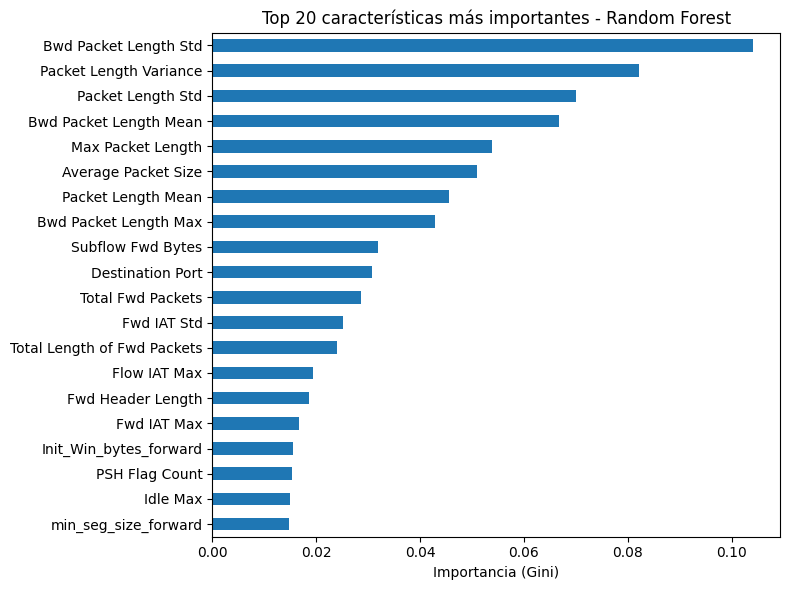

Bwd Packet Length Std          0.104098
Packet Length Variance         0.082167
Packet Length Std              0.070122
Bwd Packet Length Mean         0.066729
Max Packet Length              0.053796
Average Packet Size            0.051017
Packet Length Mean             0.045602
Bwd Packet Length Max          0.042941
Subflow Fwd Bytes              0.031952
Destination Port               0.030772
Total Fwd Packets              0.028567
Fwd IAT Std                    0.025145
Total Length of Fwd Packets    0.024083
Flow IAT Max                   0.019439
Fwd Header Length              0.018546
Fwd IAT Max                    0.016714
Init_Win_bytes_forward         0.015490
PSH Flag Count                 0.015293
Idle Max                       0.015030
min_seg_size_forward           0.014761
dtype: float64


In [7]:
# Variable objetivo: Severity
y_all = LabelEncoder().fit_transform(df["Severity"])

# Variables predictoras (eliminar las columnas objetivo)
X_all = df.drop(
    columns=["Attack Type", "Severity"]
).select_dtypes(include=[np.number])

print("Dimensiones de X:", X_all.shape)
print("Dimensiones de y:", y_all.shape)

# División entrenamiento/prueba
X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(
    X_all,
    y_all,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_all
)

# Random Forest para estimar importancia de variables
rf_probe = RandomForestClassifier(
    n_estimators=150,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_probe.fit(X_train_tmp, y_train_tmp)

# Importancias
importances = pd.Series(
    rf_probe.feature_importances_,
    index=X_all.columns
).sort_values(ascending=False)

# Visualización
plt.figure(figsize=(8, 6))
importances.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importancia (Gini)")
plt.title("Top 20 características más importantes - Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

# Mostrar ranking
print(importances.head(20))


## 7. Selección final de features

Con base en el gráfico anterior y en la literatura sobre CIC-IDS2017, se seleccionan features de cinco grupos
(volumen, estructura de paquetes, flags TCP, temporización, ventana/sesión).

In [8]:
selected_features = [
    "Bwd Packet Length Std",
    "Packet Length Variance",
    "Packet Length Std",
    "Bwd Packet Length Mean",
    "Max Packet Length",
    "Average Packet Size",
    "Packet Length Mean",
    "Bwd Packet Length Max",
    "Subflow Fwd Bytes",
    "Destination Port",
    "Total Fwd Packets",
    "Fwd IAT Std",
    "Total Length of Fwd Packets",
    "Flow IAT Max",
    "Fwd Header Length",
    "Fwd IAT Max",
    "Init_Win_bytes_forward",
    "PSH Flag Count",
    "Idle Max",
    "min_seg_size_forward"
]

selected_features = importances.head(15).index.tolist()

X = df[selected_features]
y = df["Severity"]

print(f"Features usadas: {len(selected_features)}")
print(selected_features)


Features usadas: 15
['Bwd Packet Length Std', 'Packet Length Variance', 'Packet Length Std', 'Bwd Packet Length Mean', 'Max Packet Length', 'Average Packet Size', 'Packet Length Mean', 'Bwd Packet Length Max', 'Subflow Fwd Bytes', 'Destination Port', 'Total Fwd Packets', 'Fwd IAT Std', 'Total Length of Fwd Packets', 'Flow IAT Max', 'Fwd Header Length']


## 8. Split, balanceo (SMOTE) y escalado



In [9]:
# Codificación de la variable objetivo
le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Mapeo de clases:")
print(dict(zip(le.classes_, range(len(le.classes_)))))

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

# Escalado
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sampling_strategy = {
    0: 300000,  # Alto
    1: 300000,  # Bajo
    3: 300000,  # Crítico
    4: 300000   # Medio
}

# Balanceo con SMOTE (controlado)
smote = SMOTE(
    sampling_strategy=sampling_strategy,
    random_state=RANDOM_STATE
)

X_train_bal, y_train_bal = smote.fit_resample(
    X_train_scaled,
    y_train
)

# Verificación de resultados
print("\nDistribución balanceada:")
print(Counter(y_train_bal))

print("\nDistribución original de entrenamiento:")
print(np.bincount(y_train))

print("\nDistribución balanceada:")
print(np.bincount(y_train_bal))

print("\nTamaño X_train original:", X_train.shape)
print("Tamaño X_train balanceado:", X_train_bal.shape)


Mapeo de clases:
{'Alto': 0, 'Bajo': 1, 'Benigno': 2, 'Critico': 3, 'Medio': 4}

Distribución original:
Counter({np.int64(2): 1571172, np.int64(0): 241319, np.int64(1): 68020, np.int64(4): 8470, np.int64(3): 1461})

Distribución balanceada:
Counter({np.int64(2): 1571172, np.int64(0): 300000, np.int64(1): 300000, np.int64(4): 300000, np.int64(3): 300000})

Distribución original de entrenamiento:
[ 241319   68020 1571172    1461    8470]

Distribución balanceada:
[ 300000  300000 1571172  300000  300000]

Tamaño X_train original: (1890442, 15)
Tamaño X_train balanceado: (2771172, 15)


## 9. Entrenamiento del modelo de triage (XGBoost)

In [10]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(
    X_train_bal,
    y_train_bal,
    eval_set=[(X_test_scaled, y_test)],
    verbose=True
)



[0]	validation_0-mlogloss:0.72579
[1]	validation_0-mlogloss:0.63875
[2]	validation_0-mlogloss:0.56807
[3]	validation_0-mlogloss:0.50913
[4]	validation_0-mlogloss:0.45869
[5]	validation_0-mlogloss:0.41503
[6]	validation_0-mlogloss:0.37642
[7]	validation_0-mlogloss:0.34282
[8]	validation_0-mlogloss:0.31295
[9]	validation_0-mlogloss:0.28678
[10]	validation_0-mlogloss:0.26295
[11]	validation_0-mlogloss:0.24181
[12]	validation_0-mlogloss:0.22255
[13]	validation_0-mlogloss:0.20525
[14]	validation_0-mlogloss:0.18918
[15]	validation_0-mlogloss:0.17499
[16]	validation_0-mlogloss:0.16247
[17]	validation_0-mlogloss:0.15086
[18]	validation_0-mlogloss:0.14027
[19]	validation_0-mlogloss:0.13074
[20]	validation_0-mlogloss:0.12221
[21]	validation_0-mlogloss:0.11449
[22]	validation_0-mlogloss:0.10746
[23]	validation_0-mlogloss:0.10134
[24]	validation_0-mlogloss:0.09583
[25]	validation_0-mlogloss:0.09082
[26]	validation_0-mlogloss:0.08620
[27]	validation_0-mlogloss:0.08207
[28]	validation_0-mlogloss:0.0

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1, num_class=5, ...)

## 10. Evaluación (métricas exigidas por la guía: precisión, recall, F1, AUC)

              precision    recall  f1-score   support

        Alto     0.9969    0.9948    0.9958     80440
        Bajo     0.9887    0.9990    0.9938     22674
     Benigno     0.9991    0.9886    0.9938    523724
     Critico     0.1278    0.9692    0.2258       487
       Medio     0.5522    0.9947    0.7102      2823

    accuracy                         0.9898    630148
   macro avg     0.7329    0.9893    0.7839    630148
weighted avg     0.9958    0.9898    0.9922    630148



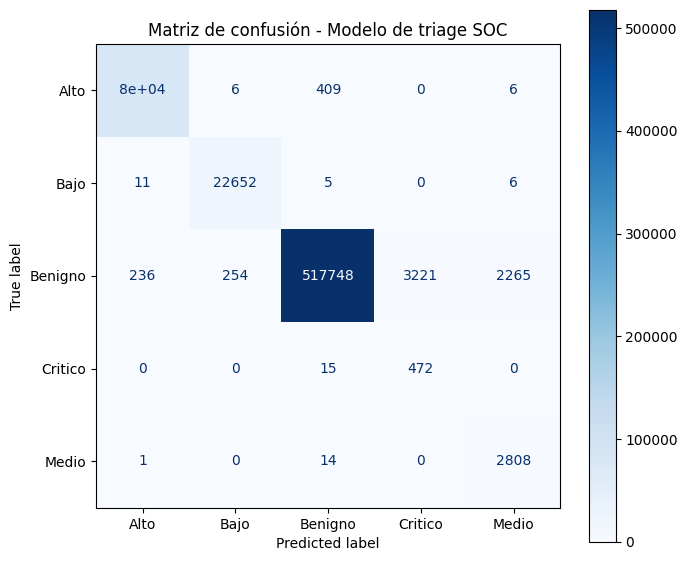


Métricas globales:


,Metrica,Valor
0,Accuracy,0.9898
1,Precision,0.9958
2,Recall,0.9898
3,F1-score,0.9922
4,AUC,0.9997


In [ ]:
# Predicciones
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)

# Reporte de clasificación
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        digits=4
    )
)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True
)

plt.title("Matriz de confusión - Modelo de triage SOC")
plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=150
)

plt.show()

# Métricas globales
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average="weighted"
)

auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr"
)

accuracy = (y_pred == y_test).mean()

metrics_table = pd.DataFrame({
    "Metrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "AUC"
    ],
    "Valor": [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(auc, 4)
    ]
})

print("\nMétricas globales:")
display(metrics_table)


## 11. Generación automatizada de reglas expertas (surrogate model)

A partir de patrones históricos de incidentes"*. El XGBoost entrenado arriba es un excelente clasificador, pero
es una caja negra — no produce reglas legibles por un humano, que es justamente lo que define a un **sistema
experto** en el sentido estricto (base de conocimiento explícita y motor de inferencia tipo IF-THEN).

**Técnica:** se entrena un árbol de decisión superficial (`max_depth` bajo) para que aprenda a **imitar las
predicciones del XGBoost** (no las etiquetas originales) — esto se llama "surrogate model" o "modelo espejo".
El árbol resultante es mucho menos preciso que el XGBoost, pero sus reglas sí son legibles y exportables,
y representan de forma aproximada la lógica que el modelo de caja negra aprendió de los datos históricos.

In [11]:
surrogate = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
surrogate.fit(X_train_bal, model.predict(X_train_bal))

fidelidad = surrogate.score(X_test_scaled, model.predict(X_test_scaled))
print(f"Fidelidad del surrogate respecto al XGBoost original: {fidelidad:.2%}\n")

reglas_generadas = export_text(surrogate, feature_names=selected_features)
print("=== Reglas generadas automaticamente a partir de patrones historicos ===\n")
print(reglas_generadas)

Fidelidad del surrogate respecto al XGBoost original: 92.00%

=== Reglas generadas automaticamente a partir de patrones historicos ===

|--- Destination Port <= -0.46
|   |--- Total Fwd Packets <= 0.03
|   |   |--- Destination Port <= -0.46
|   |   |   |--- class: 1
|   |   |--- Destination Port >  -0.46
|   |   |   |--- class: 4
|   |--- Total Fwd Packets >  0.03
|   |   |--- class: 2
|--- Destination Port >  -0.46
|   |--- Bwd Packet Length Std <= 1.27
|   |   |--- Bwd Packet Length Mean <= -0.47
|   |   |   |--- class: 2
|   |   |--- Bwd Packet Length Mean >  -0.47
|   |   |   |--- class: 2
|   |--- Bwd Packet Length Std >  1.27
|   |   |--- Destination Port <= -0.44
|   |   |   |--- class: 0
|   |   |--- Destination Port >  -0.44
|   |   |   |--- class: 2



In [12]:
# Conversion de las reglas del árbol a un formato tipo Sigma (YAML) -- cierra el ciclo completo:
# dataset historico -> modelo entrena -> modelo genera reglas -> reglas se llevan al SIEM
def arbol_a_sigma(texto_arbol, nombre_regla="regla_generada_automaticamente"):
    """Convierte una condicion simple del arbol (ej. 'Flow IAT Mean <= 120.50') a bloque Sigma YAML."""
    lineas = [l for l in texto_arbol.split("\n") if "<=" in l or ">" in l]
    condiciones = []
    for linea in lineas[:3]:  # primeras 3 condiciones como ejemplo
        m = re.search(r"([\w /]+)\s*(<=|>)\s*([\d.]+)", linea)
        if m:
            campo, operador, valor = m.groups()
            condiciones.append(f"    {campo.strip()}|{'lte' if operador == '<=' else 'gt'}: {valor}")

    sigma_yaml = f"""title: {nombre_regla}
status: experimental
description: Regla generada automaticamente a partir de un arbol surrogate entrenado sobre XGBoost (Tema 6)
logsource:
    category: network_flow
detection:
    selection:
{chr(10).join(condiciones)}
    condition: selection
level: medium
tags:
    - attack.t1110
"""
    return sigma_yaml

print(arbol_a_sigma(reglas_generadas))
print("\nNota: esta regla es un PROTOTIPO generado por el modelo -- debe ser revisada por un analista")
print("antes de desplegarse en produccion. Documentar esto en el Analisis Critico (Seccion 7 de la guia)")
print("como ejemplo de 'human-in-the-loop' necesario, no reemplazo total del analista.")

title: regla_generada_automaticamente
status: experimental
description: Regla generada automaticamente a partir de un arbol surrogate entrenado sobre XGBoost (Tema 6)
logsource:
    category: network_flow
detection:
    selection:
    Total Fwd Packets|lte: 0.03
    condition: selection
level: medium
tags:
    - attack.t1110


Nota: esta regla es un PROTOTIPO generado por el modelo -- debe ser revisada por un analista
antes de desplegarse en produccion. Documentar esto en el Analisis Critico (Seccion 7 de la guia)
como ejemplo de 'human-in-the-loop' necesario, no reemplazo total del analista.


## 12. Interpretabilidad (SHAP): Análisis crítico

/tmp/ipykernel_443/2466423200.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


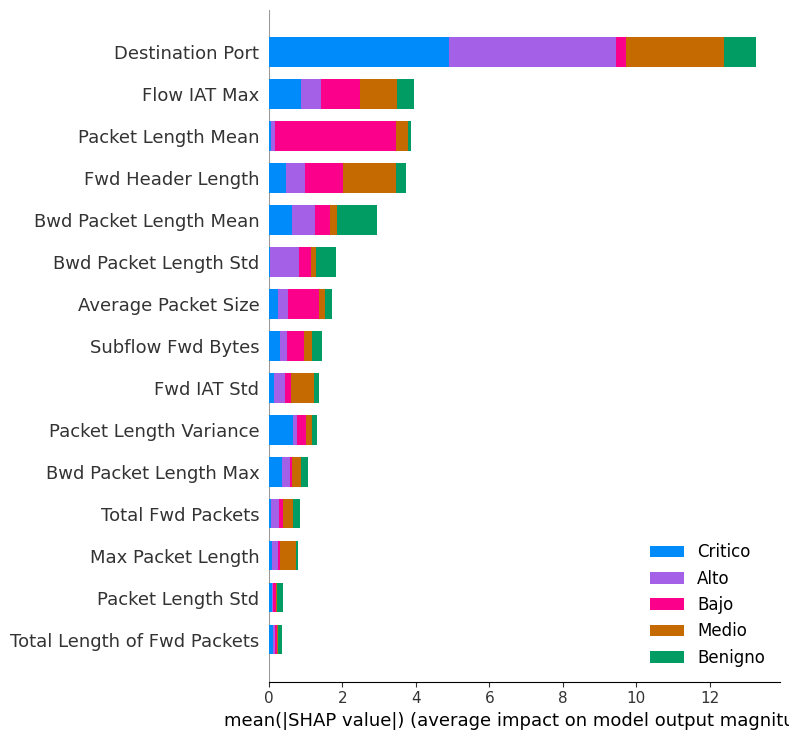

In [13]:
# SHAP Explainability
sample_size = 500

X_shap = X_test_scaled[:sample_size]

explainer = shap.TreeExplainer(model)

shap_values = explainer(X_shap)

plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=selected_features,
    class_names=le.classes_,
    show=False
)

plt.tight_layout()

plt.savefig(
    "shap_summary.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()



## 13. Simulación en vivo

Se toma un lote del set de prueba y se procesa fila por fila "como si" fuera tráfico entrante en tiempo real,
mostrando la clasificación de severidad de cada flujo.

In [14]:
def clasificar_flujo_entrante(fila_escalada, modelo, encoder):
    proba = modelo.predict_proba(fila_escalada.reshape(1, -1))[0]
    clase = np.argmax(proba)

    return (
        encoder.classes_[clase],
        proba[clase],
        proba
    )

print("=== Simulación de tráfico entrante ===\n")

muestra = X_test_scaled[:15]
etiquetas_reales = le.inverse_transform(y_test[:15])

for i, fila in enumerate(muestra):

    severidad, confianza, probabilidades = clasificar_flujo_entrante(
        fila,
        model,
        le
    )

    print(
        f"Flujo {i+1:02d} | "
        f"Predicción: {severidad:<8} | "
        f"Confianza: {confianza:.2%} | "
        f"Real: {etiquetas_reales[i]}"
    )

    time.sleep(0.3)


=== Simulación de tráfico entrante ===

Flujo 01 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 02 | Predicción: Alto     | Confianza: 100.00% | Real: Alto
Flujo 03 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 04 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 05 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 06 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 07 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 08 | Predicción: Bajo     | Confianza: 99.99% | Real: Bajo
Flujo 09 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 10 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 11 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 12 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 13 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
Flujo 14 | Predicción: Benigno  | Confianza: 100.00% | Real: Benigno
F

## 14. Automatización de respuesta (integración conceptual con Shuffle SOAR)



In [15]:
SHUFFLE_WEBHOOK_URL = "https://your-shuffle-instance/api/v1/hooks/webhook_id"  # reemplazar

acciones_por_severidad = {
    "Bajo": "Registrar en log, sin accion automatica",
    "Medio": "Crear ticket en cola SOC para revision manual",
    "Alto": "Bloquear IP origen y notificar analista de guardia",
    "Critico": "Aislar host, bloquear IP, escalar a Tier 2 de inmediato",
}

def disparar_respuesta(severidad, ip_origen="10.0.0.X", enviar_real=False):
    accion = acciones_por_severidad.get(severidad, "Sin accion definida")
    payload = {"severidad": severidad, "ip_origen": ip_origen, "accion": accion}

    if enviar_real:
        try:
            resp = requests.post(SHUFFLE_WEBHOOK_URL, json=payload, timeout=5)
            print(f"Webhook enviado a Shuffle -> status {resp.status_code}")
        except Exception as e:
            print(f"No se pudo contactar Shuffle: {e}")
    else:
        print(f"[SIMULADO] Severidad={severidad} -> Accion: {accion}")

# Ejemplo de uso dentro del loop de simulación
disparar_respuesta("Alto", ip_origen="192.168.1.55", enviar_real=False)


[SIMULADO] Severidad=Alto -> Accion: Bloquear IP origen y notificar analista de guardia


## 15. Dashboard con ipywidgets

In [16]:
# Respuestas SOC automáticas (simuladas)
acciones_por_severidad = {
    "Benigno": "Permitir trafico y registrar evento",
    "Bajo": "Registrar en log, sin accion automatica",
    "Medio": "Crear ticket SOC",
    "Alto": "Bloquear IP y notificar analista",
    "Critico": "Aislar host y escalar a Tier 2"
}

def disparar_respuesta(severidad):
    return acciones_por_severidad.get(
        severidad,
        "Sin accion definida"
    )

# Features más importantes encontradas
top_features = [
    "Destination Port",
    "Flow IAT Max",
    "Packet Length Mean"
]

# Selector
selector = widgets.Dropdown(
    options=[
        "Aleatoria",
        "Benigno",
        "Bajo",
        "Medio",
        "Alto",
        "Critico"
    ],
    value="Aleatoria",
    description="Modo:"
)

boton = widgets.Button(
    description="Simular flujo entrante",
    button_style="info",
    icon="shield"
)

salida = widgets.Output()

# Dashboard
def al_hacer_clic(b):

    with salida:

        clear_output()

        clases_test = le.inverse_transform(y_test)

        if selector.value == "Aleatoria":

            idx = np.random.randint(
                0,
                len(X_test_scaled)
            )

        else:

            idxs = np.where(
                clases_test == selector.value
            )[0]

            idx = np.random.choice(idxs)

        fila_escalada = X_test_scaled[idx]

        severidad, confianza, _ = clasificar_flujo_entrante(
            fila_escalada,
            model,
            le
        )

        # Contexto usando datos sin escalar
        contexto = X_test.iloc[idx]

        print("=== TRIAGE SOC ===")
        print(f"Severidad detectada : {severidad}")
        print(f"Confianza           : {confianza:.2%}")
        print()

        print("=== CONTEXTO ===")

        for feature in top_features:

            if feature in contexto.index:
                print(
                    f"{feature:<22}: "
                    f"{contexto[feature]}"
                )

        print()

        print("=== EXPLICACIÓN ===")

        for i, feature in enumerate(
            top_features,
            start=1
        ):
            print(f"{i}. {feature}")

        print()

        print("=== RESPUESTA ===")

        print(
            disparar_respuesta(severidad)
        )

boton.on_click(al_hacer_clic)

display(selector, boton, salida)


Dropdown(description='Modo:', options=('Aleatoria', 'Benigno', 'Bajo', 'Medio', 'Alto', 'Critico'), value='Ale…

Button(button_style='info', description='Simular flujo entrante', icon='shield', style=ButtonStyle())

Output()

## 16. Guardado del modelo (reproducibilidad)

In [17]:
# Guardar artefactos del modelo
joblib.dump(model, "modelo_triage_soc.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(le, "label_encoder.joblib")
joblib.dump(selected_features, "selected_features.joblib")

# Metadatos del modelo
metadata = {
    "modelo": "XGBoost",
    "target": "Severity",
    "num_features": len(selected_features),
    "features": selected_features,
    "clases": list(le.classes_)
}

joblib.dump(metadata, "metadata.joblib")

# Confirmación
print("Modelo y artefactos guardados correctamente.\n")

print("Archivos generados:")
print(" - modelo_triage_soc.joblib")
print(" - scaler.joblib")
print(" - label_encoder.joblib")
print(" - selected_features.joblib")
print(" - metadata.joblib")

print("\nClases del modelo:")
print(list(le.classes_))

print("\nFeatures utilizadas:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feature}")

print("\nListo para subir al repositorio o desplegar en producción.")

Modelo y artefactos guardados correctamente.

Archivos generados:
 - modelo_triage_soc.joblib
 - scaler.joblib
 - label_encoder.joblib
 - selected_features.joblib
 - metadata.joblib

Clases del modelo:
['Alto', 'Bajo', 'Benigno', 'Critico', 'Medio']

Features utilizadas:
01. Bwd Packet Length Std
02. Packet Length Variance
03. Packet Length Std
04. Bwd Packet Length Mean
05. Max Packet Length
06. Average Packet Size
07. Packet Length Mean
08. Bwd Packet Length Max
09. Subflow Fwd Bytes
10. Destination Port
11. Total Fwd Packets
12. Fwd IAT Std
13. Total Length of Fwd Packets
14. Flow IAT Max
15. Fwd Header Length

Listo para subir al repositorio o desplegar en producción.
